Setup

In [1]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg

jlPkg.activate("../../.")
jl.include("rl_repressilator_setup.jl")
#jlPkg.instantiate() #run the first time using this repo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


evaluate_params (generic function with 1 method)

Second peak value: 0.7038096038235359


In [2]:
from gymnasium.utils import seeding
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import tensorboard
import os

import random
import torch
from gymnasium.utils import seeding

class CustomEnv(gym.Env):
    
    def __init__(self):
        super(CustomEnv, self).__init__()
        # Define action and observation space
        self.action_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32) # Example: two discrete actions
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(1,), dtype=np.float32)  # Example: 3-dimensional observation
        self.episode_counter = 0


    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")
        return [seed]


    def reset(self, seed=None, options=None):
        # Reset the state of the environment to an initial state
        if seed is not None:
            self.seed(seed)
          
        self.episode_counter = 0
        obs = np.array([0], dtype=np.float32)
         # Ensure the observation is of type float32
        info = {}  # Example: additional information
        return obs, info

    def step(self, action):
        # Execute one time step within the environment
        rew = jl.reward(action)
        obs = np.array([0], dtype=np.float32)
        
        terminated = True  # Example: whether the episode has ended
        truncated = False  # Example: whether the episode was truncated
        info = {}  # Example: additional information
        return obs, rew, terminated, truncated, info
    
env = CustomEnv()
check_env(env)

Training

In [140]:
# Running this cell will overide any existing monitors
log_dir = "logs/rl_repressilator/"
os.makedirs(log_dir, exist_ok=True)

# =============================== #
# ✅ Monitor environment for logging
# =============================== #

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # your Julia seed
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

model = PPO(
    "MlpPolicy", 
    env,
    verbose=1,
    tensorboard_log=log_dir,   # Optional: enables TensorBoard
    seed=SEED
)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [141]:
# Train the model
model.learn(total_timesteps=10)
# runtime 51min 44s

# Save the model
model.save(os.path.join(log_dir, "ppo_model"))

Logging to logs/rl_repressilator/PPO_15
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | 0.0904   |
| time/              |          |
|    fps             | 40       |
|    iterations      | 1        |
|    time_elapsed    | 50       |
|    total_timesteps | 2048     |
---------------------------------


Evaluation

In [3]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

# ==== Configuration ====
log_dir = "logs/rl_repressilator"
model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

model = PPO.load(model_path)


df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

C:\Users\micha\AppData\Local\Temp\ipykernel_5504\3935325265.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


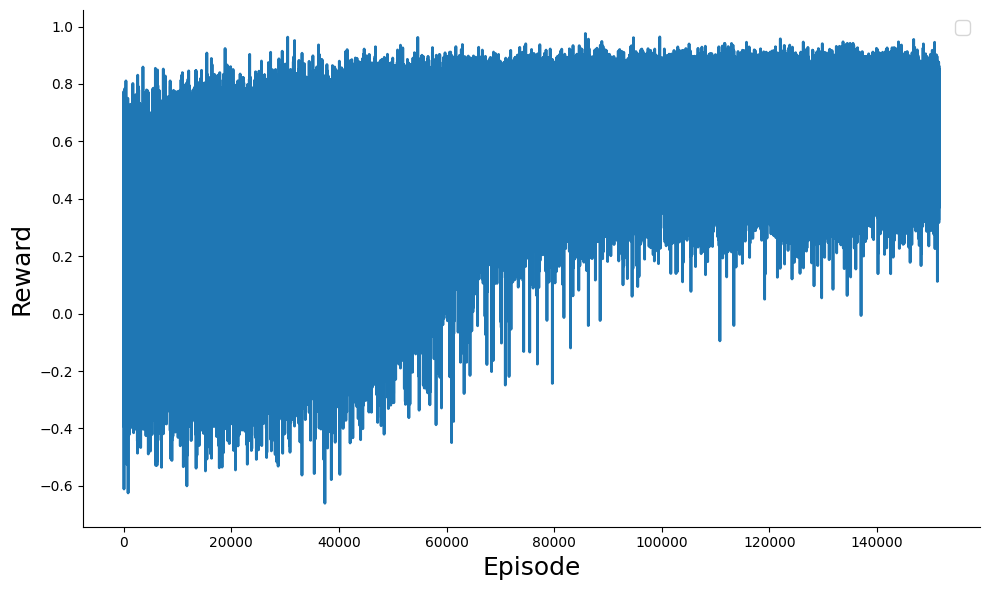

In [4]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(df)), y=df["r"], linewidth=2)

plt.xlabel("Episode", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()


In [5]:
# Store actions in a list
actions = []

# Generate 1000 samples
for _ in range(100000):
    # Reset env with random hidden_state (as in your example)
    obs, info = env.reset()
    
    # Predict action
    action, _states = model.predict(obs, deterministic=False)  # deterministic=False for stochastic sampling
    actions.append(jl.denormalize_params(action))

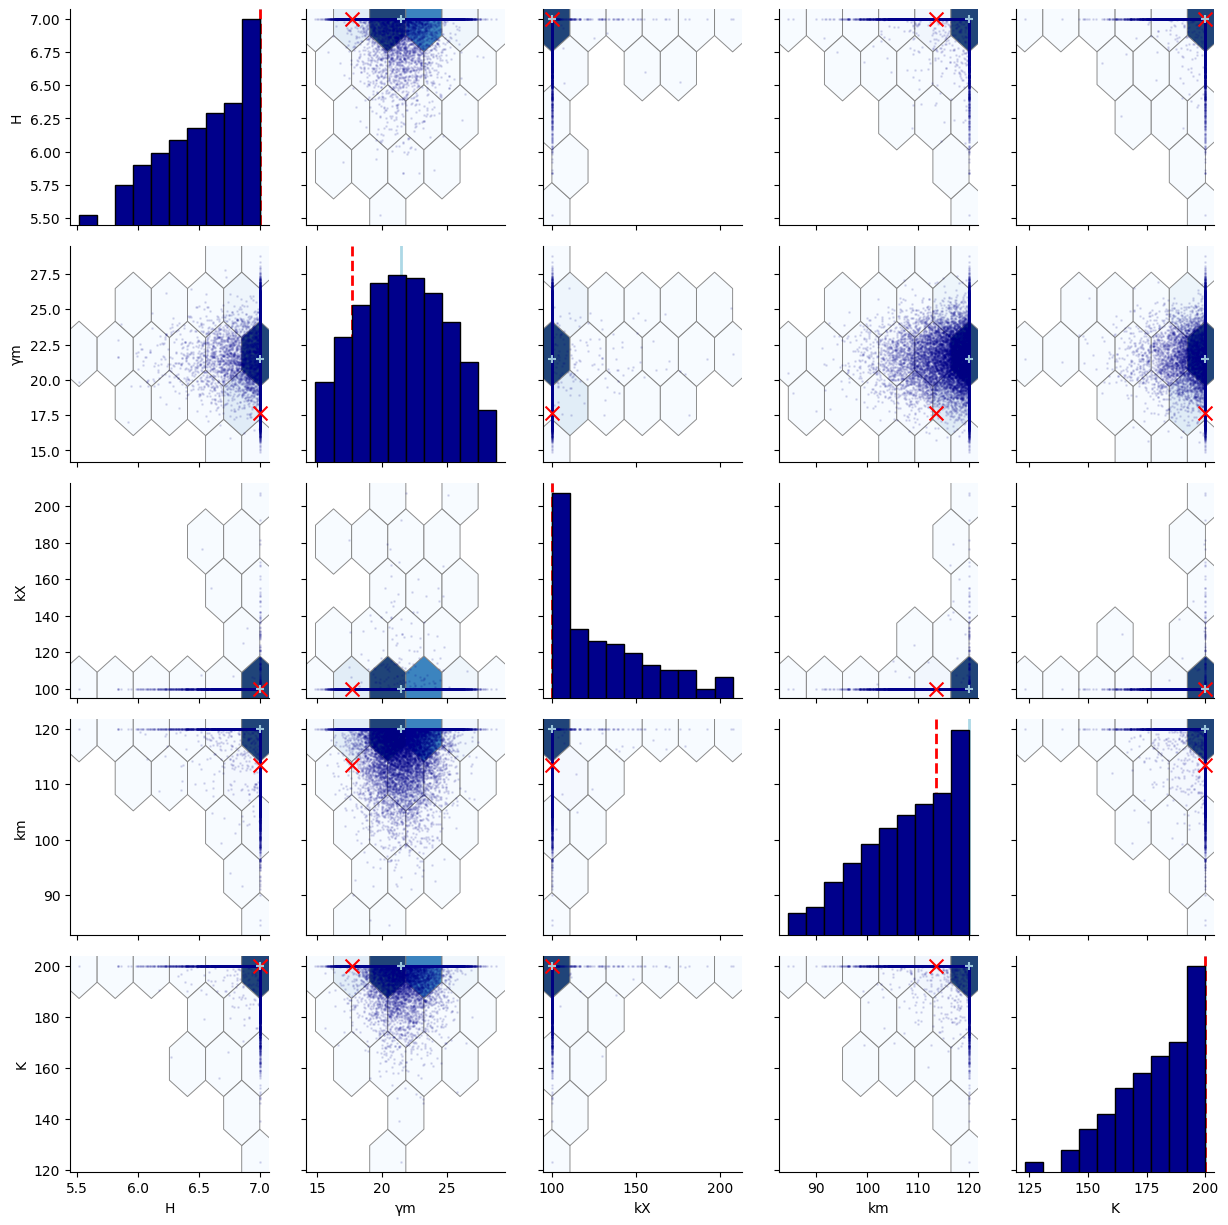

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the DataFrame
df = pd.DataFrame(actions, columns=["H", "γm", "kX", "km", "K"])

# Define ground truth and deterministic prediction
gt = [7.0, 17.6822, 100.0, 113.4372, 199.8989]
action_determinstic = model.predict(obs, deterministic=True)[0]
action_determinstic_denormalized = jl.denormalize_params(action_determinstic)

# Hexbin plot function
def hexbin_plot(x, y, color, **kwargs):
    ax = plt.gca()
    ax.hexbin(
        x, y,
        gridsize=5,
        cmap='Blues',
        mincnt=1,
        edgecolors='gray',
        linewidths=0.7,
        alpha=0.9
    )

# Histogram function for diagonal
def hist_plot(x, color, **kwargs):
    ax = plt.gca()
    ax.hist(x, bins=10, color='darkblue', edgecolor='black',log=True)

# Initialize PairGrid
g = sns.PairGrid(df)
g.map_lower(hexbin_plot)
g.map_diag(hist_plot)
g.map_upper(hexbin_plot)

# Overlay scatter points and vertical lines
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        ax = g.axes[row, col]

        if row == col:
            # Add vertical lines to diagonal
            ax.axvline(action_determinstic_denormalized[row], color='lightblue',zorder=10, linewidth=2, label='Deterministic' if row == 0 else "")
            ax.axvline(gt[row], color='red', linestyle='--', linewidth=2, zorder=10, label='Ground Truth' if row == 0 else "")
        else:
            ax.scatter(df.iloc[:, col], df.iloc[:, row],
                       color='darkblue', s=1, alpha=0.1, label='Samples' if (row, col) == (1, 0) else "")
            ax.scatter(gt[col], gt[row],
                       color='red', s=100,marker='x', label='Ground Truth' if (row, col) == (1, 0) else "")
            ax.scatter(action_determinstic_denormalized[col], action_determinstic_denormalized[row],
                       color='lightblue', marker="+", alpha=0.9, label='Deterministic' if (row, col) == (1, 0) else "")

# Add legend only once
handles, labels = g.axes[-1][0].get_legend_handles_labels()
if handles:
    g.axes[-1][0].legend(handles, labels, loc='upper right', fontsize='small')

plt.show()


In [7]:
stochastic_policy_result = []
for i in range(1000):
    action = model.predict(obs)[0]
    stochastic_policy_result.append(jl.reward(action))

action_determinstic = model.predict(obs, deterministic=True)[0]

policy_det_eval = jl.evaluate_params(action_determinstic)

sequiros_eval = jl.evaluate_params(jl.normalize_params(np.array(gt, dtype=np.float32)))



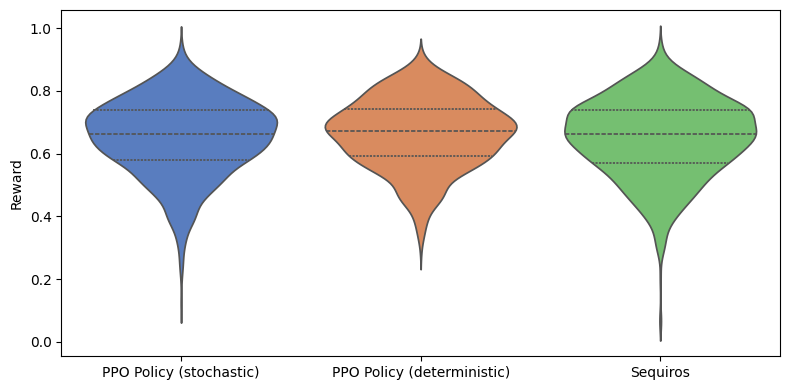

mean of policy_det_eval: 0.6635117965051814
mean of policy_stoch_eval: 0.6518445603201541
mean of sequiros_eval: 0.6493220805215304


In [8]:

plt.figure(figsize=(8, 4))
sns.violinplot(data=[stochastic_policy_result, policy_det_eval, sequiros_eval], inner="quartile", palette="muted")
plt.xticks([0, 1, 2], ['PPO Policy (stochastic)','PPO Policy (deterministic)', 'Sequiros'])
plt.ylabel('Reward')
plt.tight_layout()
plt.show()

print("mean of policy_det_eval:", np.mean(policy_det_eval))
print("mean of policy_stoch_eval:", np.mean(stochastic_policy_result))
print("mean of sequiros_eval:", np.mean(sequiros_eval))